# NumPy, pandas, Matplotlib — Introduction

**Stack**
- NumPy → n-dimensional arrays, vectorized math
- pandas → tabular data, cleaning, joins, grouping
- Matplotlib → plots, charts, exports

Install:
```bash
pip install numpy pandas matplotlib jupyterlab
```

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

NumPy: 2.0.2
pandas: 2.2.2


## 1. NumPy

**Array terms**
- `ndim` → dimensions
- `shape` → size per dimension
- `dtype` → element type
- `axis=0` → rows/down
- `axis=1` → columns/across

In [ ]:
# Scalars, vectors, matrices
scalar = np.array(7)
vector = np.array([1, 2, 3, 4])
matrix = np.array([[1, 2, 3], [4, 5, 6]])

for name, arr in {"scalar": scalar, "vector": vector, "matrix": matrix}.items():
    print(f"{name}:")
    print(arr)
    print("ndim:", arr.ndim, "shape:", arr.shape, "dtype:", arr.dtype, "\n")

scalar:
7
ndim: 0 shape: () dtype: int64 

vector:
[1 2 3 4]
ndim: 1 shape: (4,) dtype: int64 

matrix:
[[1 2 3]
 [4 5 6]]
ndim: 2 shape: (2, 3) dtype: int64 



In [ ]:
# Array creation
zeros = np.zeros((2, 3))
ones = np.ones((2, 3), dtype=int)
full = np.full((2, 3), 9)
sequence = np.arange(0, 10, 2)
even_spacing = np.linspace(0, 1, 6)
identity = np.eye(3)

print("zeros:\n", zeros)
print("ones:\n", ones)
print("full:\n", full)
print("arange:", sequence)
print("linspace:", even_spacing)
print("identity:\n", identity)

zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:
 [[1 1 1]
 [1 1 1]]
full:
 [[9 9 9]
 [9 9 9]]
arange: [0 2 4 6 8]
linspace: [0.  0.2 0.4 0.6 0.8 1. ]
identity:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [ ]:
# Reshape, flatten, transpose
grid = np.arange(12).reshape(3, 4)

print("grid:\n", grid)
print("shape:", grid.shape)
print("flatten:", grid.ravel())
print("transpose:\n", grid.T)

grid:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape: (3, 4)
flatten: [ 0  1  2  3  4  5  6  7  8  9 10 11]
transpose:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


In [ ]:
# Indexing, slicing
print("grid:\n", grid)
print("row 0:", grid[0])
print("row 1, col 2:", grid[1, 2])
print("last row:", grid[-1])
print("first 2 rows:\n", grid[:2])
print("cols 1–2:\n", grid[:, 1:3])
print("every second col:\n", grid[:, ::2])

grid:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
row 0: [0 1 2 3]
row 1, col 2: 6
last row: [ 8  9 10 11]
first 2 rows:
 [[0 1 2 3]
 [4 5 6 7]]
cols 1–2:
 [[ 1  2]
 [ 5  6]
 [ 9 10]]
every second col:
 [[ 0  2]
 [ 4  6]
 [ 8 10]]


In [ ]:
# Boolean masks, filtering
values = np.array([4, 9, 2, 15, 7, 20])

mask = values > 8
print("mask:", mask)
print("values > 8:", values[mask])
print("even:", values[values % 2 == 0])
print("replace > 8:", np.where(values > 8, 0, values))

mask: [False  True False  True False  True]
values > 8: [ 9 15 20]
even: [ 4  2 20]
replace > 8: [4 0 2 0 7 0]


In [ ]:
# Vectorized math — avoid Python loops
x = np.arange(1, 6)

print("x:", x)
print("x + 10:", x + 10)
print("x * 2:", x * 2)
print("x²:", x**2)
print("sqrt:", np.sqrt(x))
print("log:", np.log(x))
print("sin:", np.sin(x))

x: [1 2 3 4 5]
x + 10: [11 12 13 14 15]
x * 2: [ 2  4  6  8 10]
x²: [ 1  4  9 16 25]
sqrt: [1.   1.41 1.73 2.   2.24]
log: [0.   0.69 1.1  1.39 1.61]
sin: [ 0.84  0.91  0.14 -0.76 -0.96]


In [ ]:
# Broadcasting
scores = np.array([
    [70, 80, 90],
    [65, 75, 85],
    [88, 92, 96],
])

bonus_per_subject = np.array([5, 3, 2])
print("scores:\n", scores)
print("scores + bonus:\n", scores + bonus_per_subject)

row_means = scores.mean(axis=1, keepdims=True)
centered = scores - row_means

print("row means:\n", row_means)
print("row-centered scores:\n", centered)

scores:
 [[70 80 90]
 [65 75 85]
 [88 92 96]]
scores + bonus:
 [[75 83 92]
 [70 78 87]
 [93 95 98]]
row means:
 [[80.]
 [75.]
 [92.]]
row-centered scores:
 [[-10.   0.  10.]
 [-10.   0.  10.]
 [ -4.   0.   4.]]


In [ ]:
# Aggregation
print("scores:\n", scores)
print("sum:", scores.sum())
print("mean:", scores.mean())
print("min/max:", scores.min(), scores.max())
print("mean per subject:", scores.mean(axis=0))
print("mean per student:", scores.mean(axis=1))
print("std:", scores.std())
print("argmax:", scores.argmax())
print("unique:", np.unique(np.array([1, 2, 2, 3, 3, 3])))

scores:
 [[70 80 90]
 [65 75 85]
 [88 92 96]]
sum: 741
mean: 82.33333333333333
min/max: 65 96
mean per subject: [74.33 82.33 90.33]
mean per student: [80. 75. 92.]
std: 9.944289260117532
argmax: 8
unique: [1 2 3]


In [ ]:
# Sort, concatenate, stack
a = np.array([3, 1, 2])
b = np.array([6, 5, 4])

print("sorted:", np.sort(a))
print("argsort:", np.argsort(a))
print("concat:", np.concatenate([a, b]))
print("vertical stack:\n", np.vstack([a, b]))
print("horizontal stack:", np.hstack([a, b]))

sorted: [1 2 3]
argsort: [1 2 0]
concat: [3 1 2 6 5 4]
vertical stack:
 [[3 1 2]
 [6 5 4]]
horizontal stack: [3 1 2 6 5 4]


In [ ]:
# Views vs copies
original = np.arange(10)
view = original[2:6]          # Shares memory
copy = original[2:6].copy()   # Independent

view[0] = 999

print("original changed:", original)
print("copy unchanged:", copy)
print("view shares memory:", np.shares_memory(original, view))
print("copy shares memory:", np.shares_memory(original, copy))

original changed: [  0   1 999   3   4   5   6   7   8   9]
copy unchanged: [2 3 4 5]
view shares memory: True
copy shares memory: False


In [ ]:
# Random numbers — use Generator API
rng = np.random.default_rng(seed=42)

print("integers:", rng.integers(1, 10, size=5))
print("uniform:", rng.random(5))
print("normal:", rng.normal(loc=100, scale=15, size=5))
print("choice:", rng.choice(["red", "green", "blue"], size=6))

integers: [1 7 6 4 4]
uniform: [0.7  0.09 0.98 0.76 0.79]
normal: [ 99.75  87.2  113.19 111.67 100.99]
choice: ['blue' 'green' 'blue' 'green' 'green' 'green']


In [ ]:
# Linear algebra
A = np.array([[2, 1], [1, 3]])
b = np.array([8, 13])

solution = np.linalg.solve(A, b)

print("A:\n", A)
print("b:", b)
print("solution:", solution)
print("verify A @ x:", A @ solution)
print("matrix product:\n", A @ A)
print("determinant:", np.linalg.det(A))

A:
 [[2 1]
 [1 3]]
b: [ 8 13]
solution: [2.2 3.6]
verify A @ x: [ 8. 13.]
matrix product:
 [[ 5  5]
 [ 5 10]]
determinant: 5.000000000000001


### NumPy quick rules

- Prefer array ops → `arr * 2`, not loops
- Shape mismatch → inspect `.shape`
- Use `.copy()` before independent edits
- Use `axis=0` → aggregate rows; `axis=1` → aggregate columns
- Use `np.random.default_rng(seed)` → reproducible randomness

## 2. pandas

**Core objects**
- `Series` → labeled 1D column
- `DataFrame` → labeled 2D table

In [ ]:
# Series
temperatures = pd.Series(
    [18, 21, 19, 24],
    index=["Mon", "Tue", "Wed", "Thu"],
    name="temperature",
)

print(temperatures)
print("\nTuesday:", temperatures["Tue"])
print("mean:", temperatures.mean())

Mon    18
Tue    21
Wed    19
Thu    24
Name: temperature, dtype: int64

Tuesday: 21
mean: 20.5


In [ ]:
# DataFrame creation
students = pd.DataFrame(
    {
        "name": ["Ada", "Ben", "Chen", "Dia"],
        "age": [20, 21, 19, 22],
        "score": [95, 82, 88, 73],
        "attempts": [1, 2, 1, 3],
    }
)

students

,name,age,score,attempts
0,Ada,20,95,1
1,Ben,21,82,2
2,Chen,19,88,1
3,Dia,22,73,3


In [ ]:
# Inspect
print(students.head())
print("\nShape:", students.shape)
print("\nColumns:", students.columns.tolist())
print("\nDtypes:\n", students.dtypes)
print("\nInfo:")
students.info()

   name  age  score  attempts
0   Ada   20     95         1
1   Ben   21     82         2
2  Chen   19     88         1
3   Dia   22     73         3

Shape: (4, 4)

Columns: ['name', 'age', 'score', 'attempts']

Dtypes:
 name        object
age          int64
score        int64
attempts     int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      4 non-null      object
 1   age       4 non-null      int64 
 2   score     4 non-null      int64 
 3   attempts  4 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 260.0+ bytes


In [ ]:
# Numeric summary
students.describe()

,age,score,attempts
count,4.000000,4.000000,4.000000
mean,20.500000,84.500000,1.750000
std,1.290994,9.327379,0.957427
min,19.000000,73.000000,1.000000
25%,19.750000,79.750000,1.000000
50%,20.500000,85.000000,1.500000
75%,21.250000,89.750000,2.250000
max,22.000000,95.000000,3.000000


In [ ]:
# Select columns
print(students["name"])
print()
print(students[["name", "score"]])

0     Ada
1     Ben
2    Chen
3     Dia
Name: name, dtype: object

   name  score
0   Ada     95
1   Ben     82
2  Chen     88
3   Dia     73


In [ ]:
# Row selection: loc labels, iloc positions
print("loc:\n", students.loc[students["score"] >= 85, ["name", "score"]])
print("\niloc:\n", students.iloc[:2, :3])
print("\nquery:\n", students.query("age >= 20 and score >= 80"))

loc:
    name  score
0   Ada     95
2  Chen     88

iloc:
   name  age  score
0  Ada   20     95
1  Ben   21     82

query:
   name  age  score  attempts
0  Ada   20     95         1
1  Ben   21     82         2


In [ ]:
# Create, update, remove columns
students = students.assign(
    passed=students["score"] >= 80,
    score_pct=students["score"] / 100,
)

students.loc[students["score"] < 80, "status"] = "review"
students.loc[students["score"] >= 80, "status"] = "pass"

students

,name,age,score,attempts,passed,score_pct,status
0,Ada,20,95,1,True,0.95,pass
1,Ben,21,82,2,True,0.82,pass
2,Chen,19,88,1,True,0.88,pass
3,Dia,22,73,3,False,0.73,review


In [ ]:
# Filter, sort
high_scores = students.loc[students["score"] >= 85].copy()
sorted_students = students.sort_values(
    ["score", "name"],
    ascending=[False, True],
)

print("high scores:\n", high_scores)
print("\nsorted:\n", sorted_students)

high scores:
    name  age  score  attempts  passed  score_pct status
0   Ada   20     95         1    True       0.95   pass
2  Chen   19     88         1    True       0.88   pass

sorted:
    name  age  score  attempts  passed  score_pct  status
0   Ada   20     95         1    True       0.95    pass
2  Chen   19     88         1    True       0.88    pass
1   Ben   21     82         2    True       0.82    pass
3   Dia   22     73         3   False       0.73  review


In [ ]:
# Missing data
raw = pd.DataFrame(
    {
        "name": ["Ari", "Bo", "Cy"],
        "score": [88, np.nan, 76],
        "group": ["x", None, "y"],
    }
)

print("missing count:\n", raw.isna().sum())

clean = raw.assign(
    score=raw["score"].fillna(raw["score"].median()),
    group=raw["group"].fillna("unknown"),
)

print("\nclean:\n", clean)
print("\ndrop rows with missing score:\n", raw.dropna(subset=["score"]))

missing count:
 name     0
score    1
group    1
dtype: int64

clean:
   name  score    group
0  Ari   88.0        x
1   Bo   82.0  unknown
2   Cy   76.0        y

drop rows with missing score:
   name  score group
0  Ari   88.0     x
2   Cy   76.0     y


In [ ]:
# Strings
people = pd.DataFrame(
    {
        "full_name": ["Ada Lovelace", "Grace Hopper", "Alan Turing"],
        "email": ["ADA@EXAMPLE.COM", "grace@example.com", "alan@example.com"],
    }
)

people["first_name"] = people["full_name"].str.split().str[0]
people["email"] = people["email"].str.lower()
people["domain"] = people["email"].str.split("@").str[-1]

people

,full_name,email,first_name,domain
0,Ada Lovelace,ada@example.com,Ada,example.com
1,Grace Hopper,grace@example.com,Grace,example.com
2,Alan Turing,alan@example.com,Alan,example.com


In [ ]:
# Datetimes
events = pd.DataFrame(
    {
        "date": ["2025-01-05", "2025-01-18", "2025-02-02", "2025-02-20"],
        "value": [10, 15, 8, 12],
    }
)

events["date"] = pd.to_datetime(events["date"])
events["year"] = events["date"].dt.year
events["month"] = events["date"].dt.month
events["day_name"] = events["date"].dt.day_name()
events["quarter"] = events["date"].dt.quarter

events

,date,value,year,month,day_name,quarter
0,2025-01-05,10,2025,1,Sunday,1
1,2025-01-18,15,2025,1,Saturday,1
2,2025-02-02,8,2025,2,Sunday,1
3,2025-02-20,12,2025,2,Thursday,1


In [ ]:
# GroupBy + aggregation
sales = pd.DataFrame(
    {
        "region": ["East", "East", "West", "West", "North", "North"],
        "item": ["Notebook", "Pen", "Notebook", "Pen", "Notebook", "Pen"],
        "units": [120, 300, 95, 280, 140, 250],
        "revenue": [600, 450, 475, 420, 700, 375],
    }
)

region_summary = (
    sales.groupby("region", as_index=False)
    .agg(
        total_units=("units", "sum"),
        total_revenue=("revenue", "sum"),
        avg_revenue=("revenue", "mean"),
        rows=("item", "size"),
    )
    .sort_values("total_revenue", ascending=False)
)

region_summary

,region,total_units,total_revenue,avg_revenue,rows
1,North,390,1075,537.5,2
0,East,420,1050,525.0,2
2,West,375,895,447.5,2


In [ ]:
# Group transform — retain original rows
sales["region_revenue_total"] = sales.groupby("region")["revenue"].transform("sum")
sales["revenue_share"] = sales["revenue"] / sales["region_revenue_total"]

sales

,region,item,units,revenue,region_revenue_total,revenue_share
0,East,Notebook,120,600,1050,0.571429
1,East,Pen,300,450,1050,0.428571
2,West,Notebook,95,475,895,0.530726
3,West,Pen,280,420,895,0.469274
4,North,Notebook,140,700,1075,0.651163
5,North,Pen,250,375,1075,0.348837


In [ ]:
# Merge / join
customers = pd.DataFrame(
    {
        "customer_id": [101, 102, 103],
        "customer": ["Ada", "Ben", "Chen"],
        "region": ["East", "West", "North"],
    }
)

orders_small = pd.DataFrame(
    {
        "order_id": [1, 2, 3, 4],
        "customer_id": [101, 102, 101, 103],
        "amount": [120, 85, 200, 150],
    }
)

customer_orders = orders_small.merge(
    customers,
    on="customer_id",
    how="left",
    validate="many_to_one",
)

customer_orders

,order_id,customer_id,amount,customer,region
0,1,101,120,Ada,East
1,2,102,85,Ben,West
2,3,101,200,Ada,East
3,4,103,150,Chen,North


In [ ]:
# Concatenate
first_half = sales.iloc[:3]
second_half = sales.iloc[3:]

combined = pd.concat([first_half, second_half], ignore_index=True)
combined

,region,item,units,revenue,region_revenue_total,revenue_share
0,East,Notebook,120,600,1050,0.571429
1,East,Pen,300,450,1050,0.428571
2,West,Notebook,95,475,895,0.530726
3,West,Pen,280,420,895,0.469274
4,North,Notebook,140,700,1075,0.651163
5,North,Pen,250,375,1075,0.348837


In [ ]:
# Pivot: long → wide
wide_sales = sales.pivot(
    index="region",
    columns="item",
    values="revenue",
)

wide_sales

item,Notebook,Pen
region,,
East,600,450
North,700,375
West,475,420


In [ ]:
# Melt: wide → long
long_sales = (
    wide_sales.reset_index()
    .melt(
        id_vars="region",
        var_name="item",
        value_name="revenue",
    )
)

long_sales

,region,item,revenue
0,East,Notebook,600
1,North,Notebook,700
2,West,Notebook,475
3,East,Pen,450
4,North,Pen,375
5,West,Pen,420


In [ ]:
# CSV I/O
sales.to_csv("sales.csv", index=False)

loaded_sales = pd.read_csv("sales.csv")
loaded_sales.head()

,region,item,units,revenue,region_revenue_total,revenue_share
0,East,Notebook,120,600,1050,0.571429
1,East,Pen,300,450,1050,0.428571
2,West,Notebook,95,475,895,0.530726
3,West,Pen,280,420,895,0.469274
4,North,Notebook,140,700,1075,0.651163


### pandas quick rules

- `loc` → labels/conditions
- `iloc` → integer positions
- Filter then edit → add `.copy()`
- Missing values → `.isna()`, `.fillna()`, `.dropna()`
- Group summary → `.groupby(...).agg(...)`
- Combine tables → `.merge(...)`, `.concat(...)`
- Dates → `pd.to_datetime(...)`, `.dt.*`

## 3. Matplotlib

**Preferred API**
```python
fig, ax = plt.subplots()
ax.plot(...)
ax.set(...)
plt.show()
```

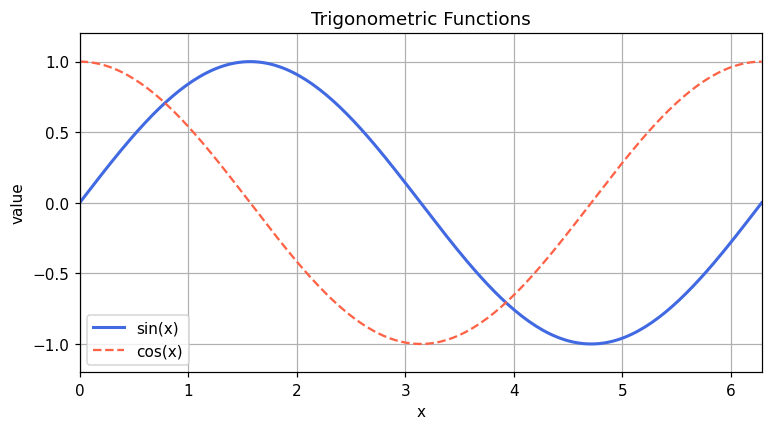

In [ ]:
# Line chart
x = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.sin(x), label="sin(x)", color="royalblue", linewidth=2)
ax.plot(x, np.cos(x), label="cos(x)", color="tomato", linestyle="--")

ax.set(
    title="Trigonometric Functions",
    xlabel="x",
    ylabel="value",
    xlim=(0, 2 * np.pi),
    ylim=(-1.2, 1.2),
)
ax.legend()
plt.show()

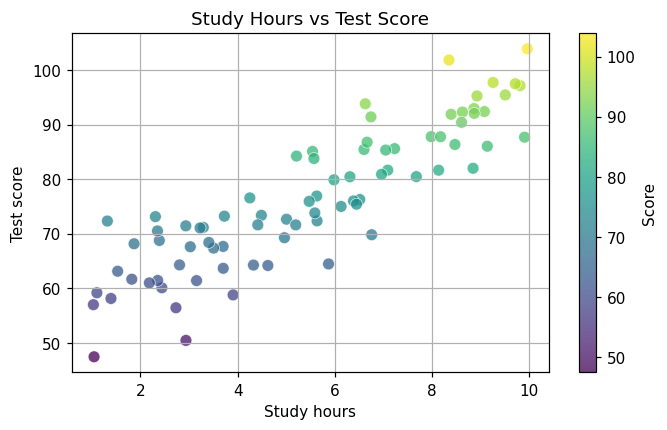

In [ ]:
# Scatter chart
rng = np.random.default_rng(7)

study_hours = rng.uniform(1, 10, 80)
test_scores = 50 + study_hours * 5 + rng.normal(0, 7, 80)

fig, ax = plt.subplots(figsize=(7, 4))
scatter = ax.scatter(
    study_hours,
    test_scores,
    c=test_scores,
    s=60,
    alpha=0.75,
    cmap="viridis",
    edgecolor="white",
    linewidth=0.5,
)

ax.set(
    title="Study Hours vs Test Score",
    xlabel="Study hours",
    ylabel="Test score",
)
fig.colorbar(scatter, ax=ax, label="Score")
plt.show()

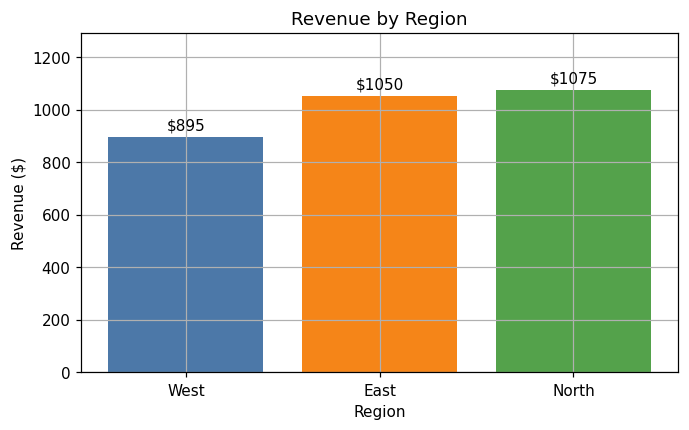

In [ ]:
# Bar chart
region_plot = region_summary.sort_values("total_revenue")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    region_plot["region"],
    region_plot["total_revenue"],
    color=["#4C78A8", "#F58518", "#54A24B"],
)

ax.bar_label(bars, fmt="$%.0f", padding=3)
ax.set(
    title="Revenue by Region",
    xlabel="Region",
    ylabel="Revenue ($)",
    ylim=(0, region_plot["total_revenue"].max() * 1.2),
)
plt.show()

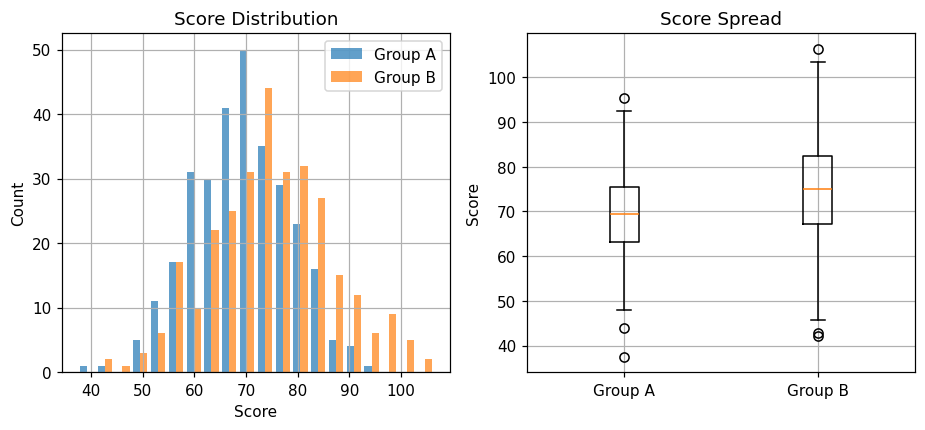

In [ ]:
# Histogram + box plot
distribution_a = rng.normal(70, 10, 300)
distribution_b = rng.normal(76, 12, 300)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(
    [distribution_a, distribution_b],
    bins=20,
    label=["Group A", "Group B"],
    alpha=0.7,
)
axes[0].set(title="Score Distribution", xlabel="Score", ylabel="Count")
axes[0].legend()

axes[1].boxplot([distribution_a, distribution_b])
axes[1].set_xticks([1, 2], ["Group A", "Group B"])
axes[1].set(title="Score Spread", ylabel="Score")

plt.show()

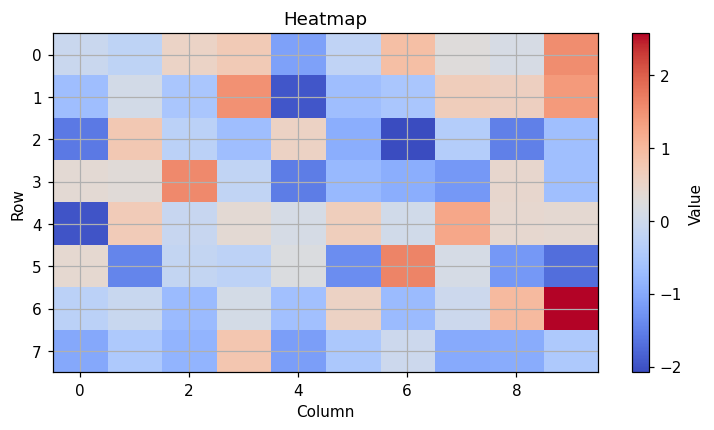

In [ ]:
# Image / heatmap
heatmap_data = rng.normal(size=(8, 10))

fig, ax = plt.subplots(figsize=(8, 4))
image = ax.imshow(heatmap_data, cmap="coolwarm", aspect="auto")

ax.set(
    title="Heatmap",
    xlabel="Column",
    ylabel="Row",
)
fig.colorbar(image, ax=ax, label="Value")
plt.show()

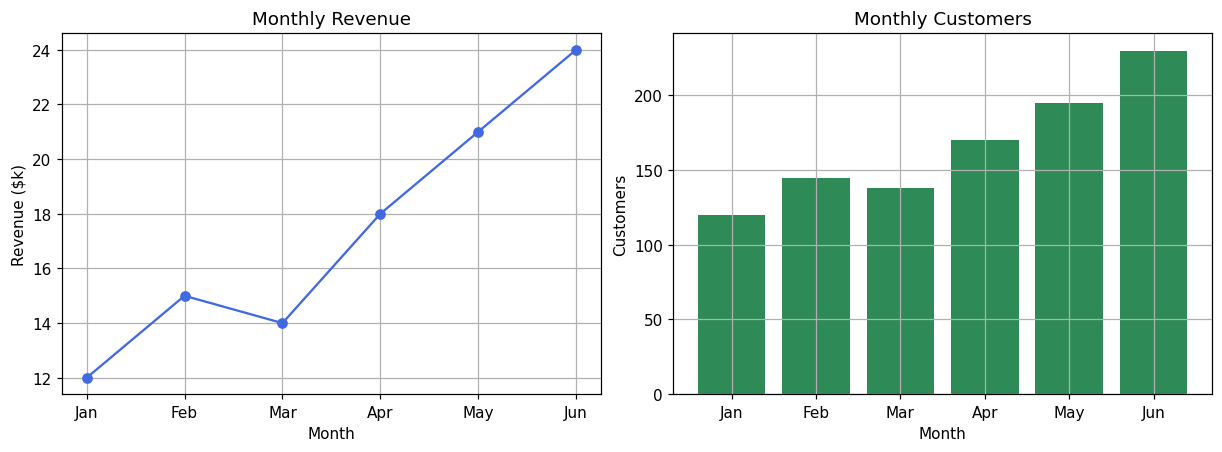

In [ ]:
# Subplots
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
revenue = [12, 15, 14, 18, 21, 24]
customers_count = [120, 145, 138, 170, 195, 230]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(months, revenue, marker="o", color="royalblue")
axes[0].set(title="Monthly Revenue", xlabel="Month", ylabel="Revenue ($k)")

axes[1].bar(months, customers_count, color="seagreen")
axes[1].set(title="Monthly Customers", xlabel="Month", ylabel="Customers")

plt.show()

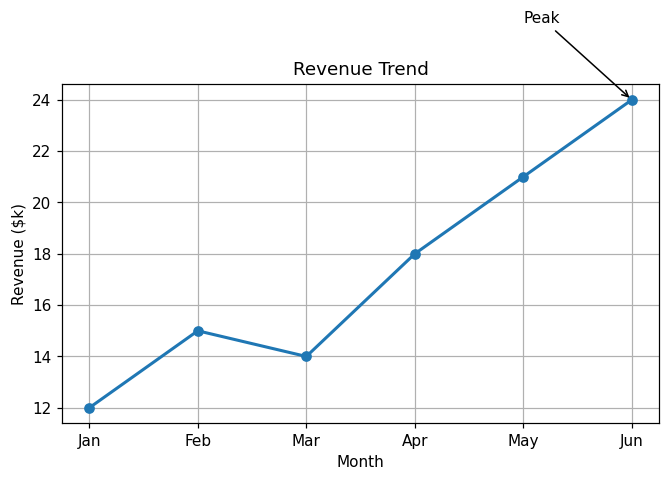

In [ ]:
# Annotation + save
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(months, revenue, marker="o", linewidth=2)

peak_idx = int(np.argmax(revenue))
ax.annotate(
    "Peak",
    xy=(months[peak_idx], revenue[peak_idx]),
    xytext=(months[peak_idx - 1], revenue[peak_idx] + 3),
    arrowprops={"arrowstyle": "->"},
)

ax.set(title="Revenue Trend", xlabel="Month", ylabel="Revenue ($k)")
fig.savefig("revenue_trend.png", dpi=180, bbox_inches="tight")
plt.show()

### Matplotlib quick rules

- `fig` → full canvas
- `ax` → one plot area
- Always add title, axis labels, units
- Use legend only when multiple series
- `fig.savefig(...)` → export PNG/PDF/SVG
- Prefer readable colors, non-truncated axes, clear scales

## 4. End-to-end mini project

Generate orders → clean/derive → summarize → plot → export.

In [ ]:
rng = np.random.default_rng(42)
n_orders = 500

orders = pd.DataFrame(
    {
        "order_id": np.arange(1, n_orders + 1),
        "date": (
            pd.Timestamp("2024-01-01")
            + pd.to_timedelta(rng.integers(0, 366, n_orders), unit="D")
        ),
        "region": rng.choice(["East", "West", "North", "South"], n_orders),
        "category": rng.choice(
            ["Books", "Electronics", "Home"],
            n_orders,
            p=[0.45, 0.25, 0.30],
        ),
        "quantity": rng.integers(1, 5, n_orders),
        "discount": rng.choice([0, 0.05, 0.10, 0.20], n_orders),
    }
)

base_prices = {
    "Books": 18.0,
    "Electronics": 120.0,
    "Home": 45.0,
}

orders["unit_price"] = orders["category"].map(base_prices)
orders["gross_revenue"] = orders["quantity"] * orders["unit_price"]
orders["revenue"] = orders["gross_revenue"] * (1 - orders["discount"])
orders["month"] = orders["date"].dt.to_period("M").dt.to_timestamp()

orders.head()

In [ ]:
# Validate
print("shape:", orders.shape)
print("\nmissing:\n", orders.isna().sum())
print("\nsummary:\n", orders.describe(include="all"))

In [ ]:
# Business summaries
category_summary = (
    orders.groupby("category", as_index=False)
    .agg(
        orders=("order_id", "size"),
        units=("quantity", "sum"),
        revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

region_summary = (
    orders.groupby("region", as_index=False)
    .agg(revenue=("revenue", "sum"))
    .sort_values("revenue", ascending=False)
)

print("Category summary:\n", category_summary)
print("\nRegion summary:\n", region_summary)

In [ ]:
# Monthly category pivot
monthly = (
    orders.groupby(["month", "category"], as_index=False)
    .agg(revenue=("revenue", "sum"))
)

monthly_wide = (
    monthly.pivot(index="month", columns="category", values="revenue")
    .fillna(0)
    .sort_index()
)

monthly_wide.head()

In [ ]:
# Plot monthly revenue
fig, ax = plt.subplots(figsize=(10, 5))

monthly_wide.plot(
    ax=ax,
    marker="o",
    linewidth=2,
)

ax.set(
    title="Monthly Revenue by Category",
    xlabel="Month",
    ylabel="Revenue ($)",
)
ax.legend(title="Category")
fig.autofmt_xdate()
plt.show()

In [ ]:
# Plot regional revenue
fig, ax = plt.subplots(figsize=(7, 4))

region_plot = region_summary.sort_values("revenue")
bars = ax.barh(
    region_plot["region"],
    region_plot["revenue"],
    color="steelblue",
)

ax.bar_label(bars, fmt="$%.0f", padding=4)
ax.set(
    title="Revenue by Region",
    xlabel="Revenue ($)",
    ylabel="Region",
)
plt.show()

In [ ]:
# Best orders
top_orders = (
    orders.nlargest(10, "revenue")
    .loc[:, ["order_id", "date", "region", "category", "quantity", "revenue"]]
)

top_orders

In [ ]:
# Export cleaned data + summary
orders.to_csv("synthetic_orders.csv", index=False)
category_summary.to_csv("category_summary.csv", index=False)
monthly_wide.to_csv("monthly_category_revenue.csv")

## 5. Practice

1. NumPy: create a `4 x 5` array; return values divisible by `3`.
2. NumPy: normalize each row so each row sums to `1`.
3. pandas: find category with highest average order value.
4. pandas: compute revenue by `region` + `month`.
5. Matplotlib: create a histogram of `orders["revenue"]`.
6. Matplotlib: create a scatter plot: `quantity` vs `revenue`, color by category.

In [ ]:
# 1
practice_array = np.arange(1, 21).reshape(4, 5)
divisible_by_three = practice_array[practice_array % 3 == 0]

print(practice_array)
print(divisible_by_three)

In [ ]:
# 2
row_sums = practice_array.sum(axis=1, keepdims=True)
normalized = practice_array / row_sums
normalized

In [ ]:
# 3
highest_aov = (
    orders.groupby("category", as_index=False)
    .agg(avg_order_value=("revenue", "mean"))
    .sort_values("avg_order_value", ascending=False)
)

highest_aov

In [ ]:
# 4
revenue_region_month = (
    orders.groupby(["region", "month"], as_index=False)
    .agg(revenue=("revenue", "sum"))
    .sort_values(["region", "month"])
)

revenue_region_month.head()

In [ ]:
# 5
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(orders["revenue"], bins=30, color="mediumpurple", edgecolor="white")
ax.set(title="Order Revenue Distribution", xlabel="Revenue ($)", ylabel="Orders")
plt.show()

In [ ]:
# 6
category_colors = {
    "Books": "royalblue",
    "Electronics": "tomato",
    "Home": "seagreen",
}

fig, ax = plt.subplots(figsize=(8, 5))

for category, subset in orders.groupby("category"):
    ax.scatter(
        subset["quantity"],
        subset["revenue"],
        label=category,
        alpha=0.55,
        color=category_colors[category],
    )

ax.set(
    title="Quantity vs Revenue",
    xlabel="Quantity",
    ylabel="Revenue ($)",
)
ax.legend(title="Category")
plt.show()